
# Recognizing Martingales in Three Ways

## Conditional expectations, drift tests, and the square-integrable stochastic-integral theorem

This notebook reproduces every figure and numerical table used in the accompanying tutorial paper. It is fully self-contained: no external dataset is required.

### What the notebook does

1. Simulates Brownian motion on a fine time grid.
2. Constructs the canonical processes
   \[
   W_t,\quad W_t^2,\quad W_t^2-t,\quad
   \int_0^t W_s\,dW_s,\quad
   \int_0^t W_s\,ds,\quad
   tW_t,\quad
   \int_0^t s\,dW_s,
   \]
   together with raw and compensated exponential processes.
3. Implements the three recognition routes:
   - the conditional-expectation definition;
   - inspection of the drift in an Itô decomposition;
   - the specialized square-integrable stochastic-integral theorem.
4. Produces seven publication-quality figures and five tables.
5. Exports every figure as a 300-dpi PNG and every table as a CSV file.

### Local requirements

The notebook uses only:

```text
numpy
pandas
matplotlib
```

Change parameters only in the configuration cell below. The default setting is designed to balance visual accuracy and memory use on an ordinary laptop.


In [1]:

from pathlib import Path
import sys
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from IPython.display import display, Markdown

# ============================================================
# USER CONFIGURATION: this is the only cell normally edited.
# ============================================================
SEED = 20260720
T = 1.0
N_STEPS = 500
N_PATHS = 12_000
THETA = 1.0
U_TIME = 0.40
N_BINS = 12

# All output files are written to a folder beside the notebook.
OUTPUT_DIR = Path.cwd() / "martingale_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")


Python: 3.13.5
Platform: Linux-4.4.0-x86_64-with-glibc2.41
Output directory: /mnt/data/martingale_tutorial_bundle/verified_run/martingale_outputs



## 1. Simulation engine

For a uniform grid \(0=t_0<t_1<\cdots<t_n=T\), Brownian increments are simulated as

\[
\Delta W_k \sim N(0,\Delta t),
\qquad
W_{t_{k+1}}=W_{t_k}+\Delta W_k.
\]

The stochastic integrals use left-endpoint Itô sums:

\[
\int_0^t H_s\,dW_s
\approx
\sum_{t_k<t} H_{t_k}\Delta W_k.
\]

The ordinary time integral uses a left Riemann sum:

\[
\int_0^t W_s\,ds
\approx
\sum_{t_k<t}W_{t_k}\Delta t.
\]


In [2]:

rng = np.random.default_rng(SEED)
dt = T / N_STEPS
time = np.linspace(0.0, T, N_STEPS + 1)

# Brownian paths
dW = rng.normal(0.0, np.sqrt(dt), size=(N_PATHS, N_STEPS))
W = np.empty((N_PATHS, N_STEPS + 1), dtype=np.float64)
W[:, 0] = 0.0
W[:, 1:] = np.cumsum(dW, axis=1)

W_left = W[:, :-1]
time_left = time[:-1]

# Canonical processes
W2 = W**2
W2_minus_t = W2 - time[None, :]
tW = W * time[None, :]

Ito_W_dW = np.empty_like(W)
Ito_W_dW[:, 0] = 0.0
Ito_W_dW[:, 1:] = np.cumsum(W_left * dW, axis=1)

Ito_s_dW = np.empty_like(W)
Ito_s_dW[:, 0] = 0.0
Ito_s_dW[:, 1:] = np.cumsum(time_left * dW, axis=1)

Time_W_ds = np.empty_like(W)
Time_W_ds[:, 0] = 0.0
Time_W_ds[:, 1:] = np.cumsum(W_left * dt, axis=1)

Exp_raw = np.exp(THETA * W)
Exp_mart = np.exp(THETA * W - 0.5 * THETA**2 * time[None, :])

# Basic numerical checks
assert W.shape == (N_PATHS, N_STEPS + 1)
assert np.allclose(W[:, 1:] - W[:, :-1], dW)
assert np.isfinite(Exp_mart).all()

print(f"Simulated {N_PATHS:,} paths with {N_STEPS:,} time steps.")
print(f"Time step dt = {dt:.6f}")
print(f"Approximate memory used by main arrays: "
      f"{sum(x.nbytes for x in [W, W2, W2_minus_t, tW, Ito_W_dW, Ito_s_dW, Time_W_ds, Exp_raw, Exp_mart]) / 1e6:.1f} MB")


Simulated 12,000 paths with 500 time steps.
Time step dt = 0.002000
Approximate memory used by main arrays: 432.9 MB



## 2. Analytical classification and numerical design

The first three tables are conceptual. They make an important distinction:

- **Route I** is the general definition.
- **Route II** is an efficient recognition device for Itô processes, but zero drift initially yields a local martingale; integrability is still required.
- **Route III** is a direct theorem for processes already written as Brownian stochastic integrals. It is not a general third definition of a martingale.

The numerical tables that follow are diagnostics rather than proofs. In particular, a constant unconditional mean does not establish the martingale property.


In [3]:

# Table 1: three routes
table1 = pd.DataFrame([
    {
        "Route": "I. Conditional-expectation definition",
        "Applicable form": "Any adapted integrable process",
        "Required check": r"E|X_t|<∞ and E[X_t|F_u]=X_u",
        "Logical conclusion": "True martingale",
        "Main strength": "General; closest to the definition",
        "Main limitation": "Conditional expectations may be difficult"
    },
    {
        "Route": "II. Itô drift inspection",
        "Applicable form": r"dX_t=a_t dt+b_t dW_t",
        "Required check": r"a_t=0 plus suitable integrability",
        "Logical conclusion": "Local martingale first; true martingale after integrability",
        "Main strength": "Fast and natural for SDEs",
        "Main limitation": "Zero drift alone is not always sufficient"
    },
    {
        "Route": "III. Square-integrable stochastic integral",
        "Applicable form": r"X_t=X_0+∫_0^t H_s dW_s",
        "Required check": r"H predictable and E∫_0^T H_s²ds<∞",
        "Logical conclusion": "Square-integrable martingale",
        "Main strength": "Direct theorem with moment formula",
        "Main limitation": "Specialized to stochastic-integral form"
    }
])

# Table 2: canonical process classification
table2 = pd.DataFrame([
    [r"$W_t$", "Martingale", r"$E_u[W_t]=W_u$", r"$dW_t=dW_t$", "Route I or II"],
    [r"$W_t^2$", "Not a martingale; submartingale", r"$E_u[W_t^2]=W_u^2+(t-u)$", r"$d(W_t^2)=dt+2W_t\,dW_t$", "Routes I and II"],
    [r"$W_t^2-t$", "Martingale", r"$E_u[W_t^2-t]=W_u^2-u$", r"$d(W_t^2-t)=2W_t\,dW_t$", "All three routes"],
    [r"$\int_0^t W_s\,dW_s$", "Square-integrable martingale", "Future Itô increment has conditional mean zero", r"$=\frac12(W_t^2-t)$", "Route III; also I and II"],
    [r"$\int_0^t W_s\,ds$", "Not a martingale", r"$E_u[X_t]=X_u+(t-u)W_u$", r"$dX_t=W_t\,dt$", "Routes I and II"],
    [r"$tW_t$", "Not a martingale", r"$E_u[tW_t]=tW_u\ne uW_u$", r"$d(tW_t)=W_t\,dt+t\,dW_t$", "Routes I and II"],
    [r"$\int_0^t s\,dW_s$", "Square-integrable martingale", "Future Itô increment has conditional mean zero", r"$dX_t=t\,dW_t$", "Route III"],
    [r"$e^{\theta W_t-\theta^2t/2}$", "Positive martingale", "Gaussian increment MGF cancels compensation", r"$dM_t=\theta M_t\,dW_t$", "Routes I and II"],
    [r"$e^{\theta W_t}$", "Not a martingale; submartingale", r"$E_u[X_t]=X_u e^{\theta^2(t-u)/2}$", "Positive drift under Itô formula", "Routes I and II"],
], columns=["Process", "Classification", "Conditional-expectation result", "Itô/drift result", "Most convenient route"])

# Table 3: simulation design
table3 = pd.DataFrame([
    ["Random seed", SEED, "Exact reproducibility"],
    ["Horizon", T, "All processes observed on [0,T]"],
    ["Time steps", N_STEPS, f"dt={dt:.6f}"],
    ["Monte Carlo paths", N_PATHS, "Ensemble moments and conditional bins"],
    ["Conditioning time u", U_TIME, "Conditional-gap experiment"],
    ["Quantile bins", N_BINS, "Approximately equal observations per bin"],
    ["Exponential parameter theta", THETA, "Raw versus compensated exponential"]
], columns=["Design element", "Value", "Purpose"])

for i, df in enumerate([table1, table2, table3], start=1):
    df.to_csv(OUTPUT_DIR / f"Table_{i}.csv", index=False)

display(table1.style.set_caption("Table 1. Comparison of the three recognition routes").hide(axis="index"))
display(table2.style.set_caption("Table 2. Classification of canonical Brownian processes").hide(axis="index"))
display(table3.style.set_caption("Table 3. Monte Carlo design").hide(axis="index"))


Route,Applicable form,Required check,Logical conclusion,Main strength,Main limitation
I. Conditional-expectation definition,Any adapted integrable process,E|X_t|<∞ and E[X_t|F_u]=X_u,True martingale,General; closest to the definition,Conditional expectations may be difficult
II. Itô drift inspection,dX_t=a_t dt+b_t dW_t,a_t=0 plus suitable integrability,Local martingale first; true martingale after integrability,Fast and natural for SDEs,Zero drift alone is not always sufficient
III. Square-integrable stochastic integral,X_t=X_0+∫_0^t H_s dW_s,H predictable and E∫_0^T H_s²ds<∞,Square-integrable martingale,Direct theorem with moment formula,Specialized to stochastic-integral form


Process,Classification,Conditional-expectation result,Itô/drift result,Most convenient route
$W_t$,Martingale,$E_u[W_t]=W_u$,$dW_t=dW_t$,Route I or II
$W_t^2$,Not a martingale; submartingale,$E_u[W_t^2]=W_u^2+(t-u)$,"$d(W_t^2)=dt+2W_t\,dW_t$",Routes I and II
$W_t^2-t$,Martingale,$E_u[W_t^2-t]=W_u^2-u$,"$d(W_t^2-t)=2W_t\,dW_t$",All three routes
"$\int_0^t W_s\,dW_s$",Square-integrable martingale,Future Itô increment has conditional mean zero,$=\frac12(W_t^2-t)$,Route III; also I and II
"$\int_0^t W_s\,ds$",Not a martingale,$E_u[X_t]=X_u+(t-u)W_u$,"$dX_t=W_t\,dt$",Routes I and II
$tW_t$,Not a martingale,$E_u[tW_t]=tW_u\ne uW_u$,"$d(tW_t)=W_t\,dt+t\,dW_t$",Routes I and II
"$\int_0^t s\,dW_s$",Square-integrable martingale,Future Itô increment has conditional mean zero,"$dX_t=t\,dW_t$",Route III
$e^{\theta W_t-\theta^2t/2}$,Positive martingale,Gaussian increment MGF cancels compensation,"$dM_t=\theta M_t\,dW_t$",Routes I and II
$e^{\theta W_t}$,Not a martingale; submartingale,$E_u[X_t]=X_u e^{\theta^2(t-u)/2}$,Positive drift under Itô formula,Routes I and II


Design element,Value,Purpose
Random seed,20260720.000000,Exact reproducibility
Horizon,1.000000,"All processes observed on [0,T]"
Time steps,500.000000,dt=0.002000
Monte Carlo paths,12000.000000,Ensemble moments and conditional bins
Conditioning time u,0.400000,Conditional-gap experiment
Quantile bins,12.000000,Approximately equal observations per bin
Exponential parameter theta,1.000000,Raw versus compensated exponential


In [4]:

# Publication-quality visual theme
COLORS = {
    "navy": "#173B57", "blue": "#2563EB", "cyan": "#0891B2",
    "teal": "#0F766E", "green": "#16A34A", "gold": "#D97706",
    "orange": "#EA580C", "red": "#DC2626", "purple": "#7C3AED",
    "pink": "#DB2777", "gray": "#64748B", "light": "#E2E8F0",
    "dark": "#0F172A"
}

mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "font.family": "DejaVu Serif",
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "lines.linewidth": 2.0
})

def save_show(fig, filename):
    fig.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)



## 3. Figure 1: the recognition architecture

The flowchart separates three logically different routes. The third route is deliberately shown as specialized: it applies when the candidate process is already a Brownian stochastic integral and its integrand satisfies an \(L^2\) condition.


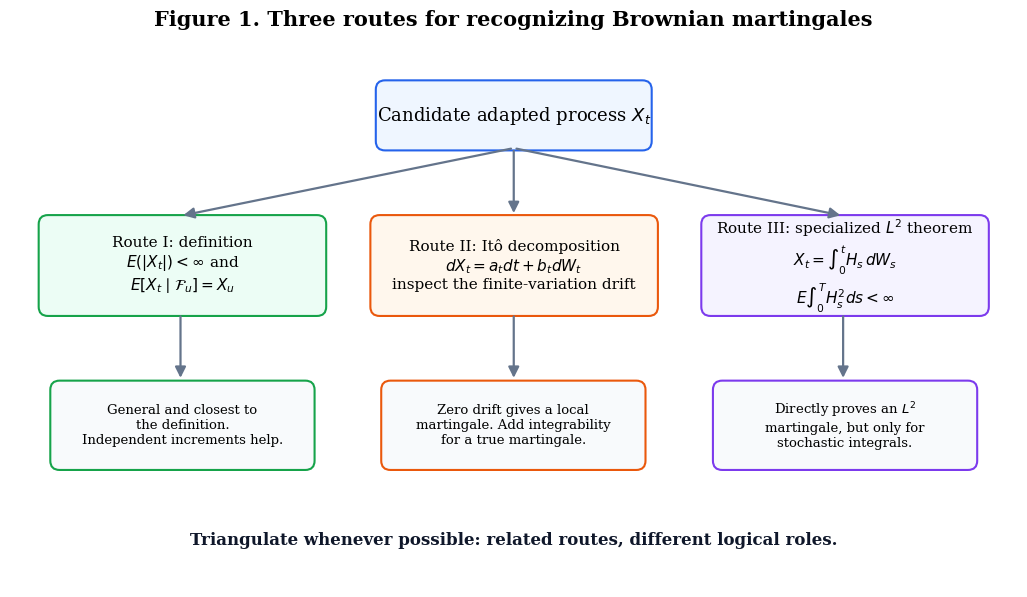

In [5]:

fig, ax = plt.subplots(figsize=(13, 7))
ax.set_xlim(0, 13)
ax.set_ylim(0, 7)
ax.axis("off")

def add_box(x, y, w, h, text, face, edge, fontsize=11):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.03,rounding_size=0.12",
        facecolor=face, edgecolor=edge, linewidth=1.5
    )
    ax.add_patch(patch)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center",
            fontsize=fontsize, multialignment="center")

def add_arrow(x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch(
        (x1, y1), (x2, y2), arrowstyle="-|>",
        mutation_scale=16, linewidth=1.6, color=COLORS["gray"]
    ))

add_box(4.75, 5.70, 3.50, 0.85, "Candidate adapted process $X_t$",
        "#EFF6FF", COLORS["blue"], 13)

add_box(0.40, 3.55, 3.65, 1.25,
        "Route I: definition\n$E(|X_t|)<\\infty$ and\n$E[X_t\\mid\\mathcal{F}_u]=X_u$",
        "#ECFDF5", COLORS["green"])

add_box(4.68, 3.55, 3.65, 1.25,
        "Route II: Itô decomposition\n$dX_t=a_tdt+b_tdW_t$\ninspect the finite-variation drift",
        "#FFF7ED", COLORS["orange"])

add_box(8.95, 3.55, 3.65, 1.25,
        "Route III: specialized $L^2$ theorem\n$X_t=\\int_0^t H_s\\,dW_s$\n$E\\int_0^T H_s^2ds<\\infty$",
        "#F5F3FF", COLORS["purple"])

add_arrow(6.50, 5.70, 2.20, 4.82)
add_arrow(6.50, 5.70, 6.50, 4.82)
add_arrow(6.50, 5.70, 10.75, 4.82)

add_box(0.55, 1.55, 3.35, 1.10,
        "General and closest to\nthe definition.\nIndependent increments help.",
        "#F8FAFC", COLORS["green"], 9.5)

add_box(4.82, 1.55, 3.35, 1.10,
        "Zero drift gives a local\nmartingale. Add integrability\nfor a true martingale.",
        "#F8FAFC", COLORS["orange"], 9.5)

add_box(9.10, 1.55, 3.35, 1.10,
        "Directly proves an $L^2$\nmartingale, but only for\nstochastic integrals.",
        "#F8FAFC", COLORS["purple"], 9.5)

add_arrow(2.20, 3.55, 2.20, 2.68)
add_arrow(6.50, 3.55, 6.50, 2.68)
add_arrow(10.75, 3.55, 10.75, 2.68)

ax.text(6.5, 0.55,
        "Triangulate whenever possible: related routes, different logical roles.",
        ha="center", fontsize=12, fontweight="bold", color=COLORS["dark"])

ax.set_title("Figure 1. Three routes for recognizing Brownian martingales", pad=16)
save_show(fig, "Figure_1_Recognition_Workflow.png")



## 4. Pathwise illustrations

A single realized path cannot prove or disprove a martingale property. It can, however, make the compensation mechanism visible. Figure 2 compares \(W_t\), \(W_t^2\), and \(W_t^2-t\) under the same Brownian shocks. Figure 3 illustrates the stochastic integration-by-parts identity

\[
tW_t=\int_0^t s\,dW_s+\int_0^t W_s\,ds.
\]

The numerical curves use finite-grid approximations, so the equality is accurate up to discretization error.


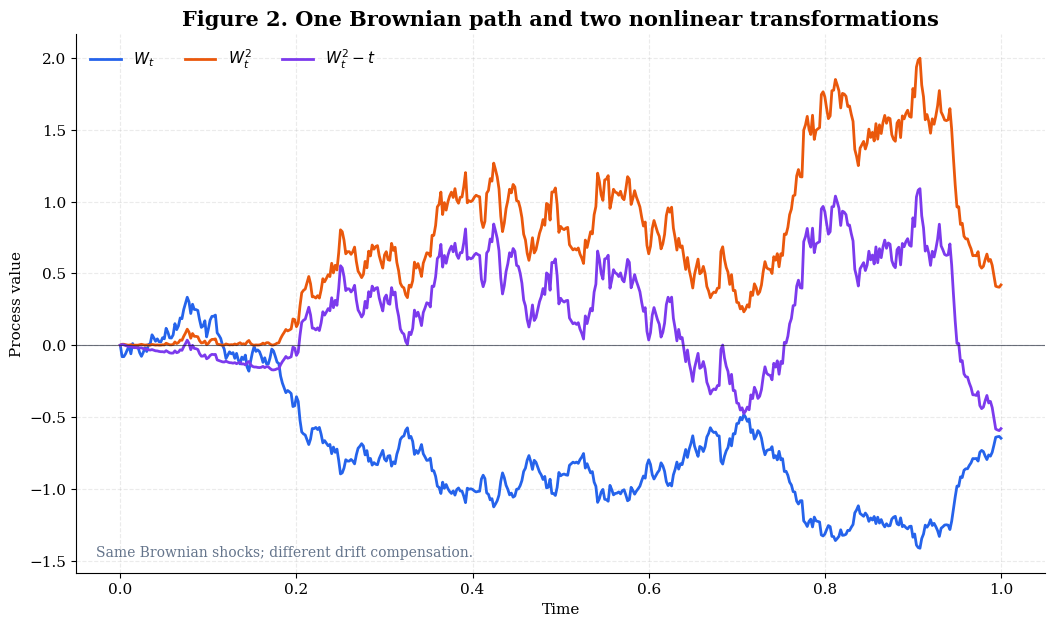

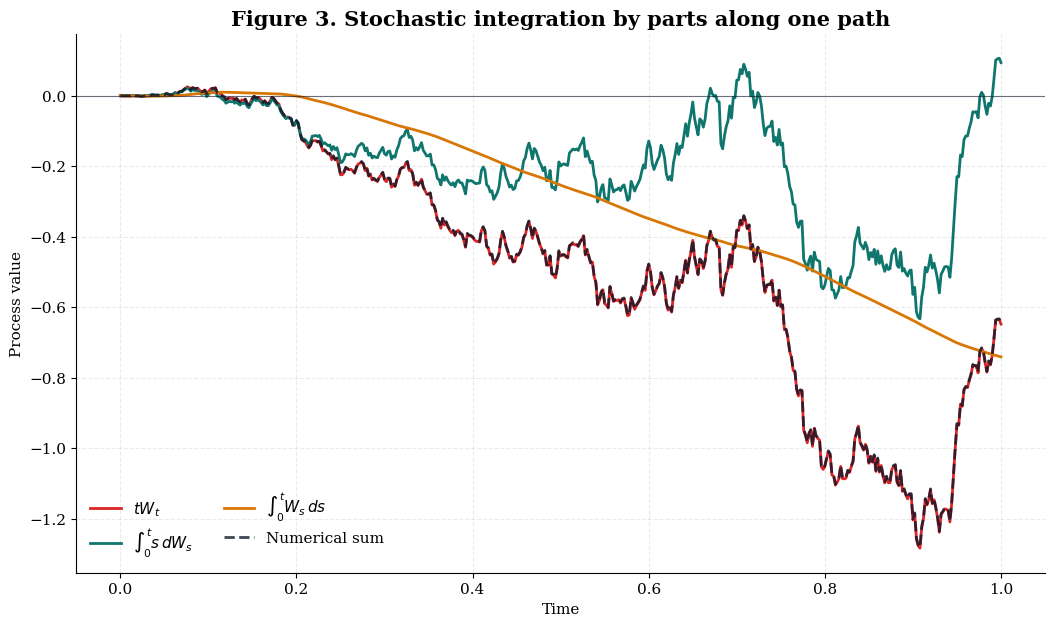

In [6]:

# Select a visually informative but fully reproducible path.
path_index = 0

fig, ax = plt.subplots(figsize=(12.5, 7))
ax.plot(time, W[path_index], label="$W_t$", color=COLORS["blue"])
ax.plot(time, W2[path_index], label="$W_t^2$", color=COLORS["orange"])
ax.plot(time, W2_minus_t[path_index], label="$W_t^2-t$", color=COLORS["purple"])
ax.axhline(0, color=COLORS["dark"], linewidth=0.8, alpha=0.6)
ax.set_xlabel("Time")
ax.set_ylabel("Process value")
ax.set_title("Figure 2. One Brownian path and two nonlinear transformations")
ax.grid(True)
ax.legend(ncol=3, loc="upper left")
ax.text(0.02, 0.03, "Same Brownian shocks; different drift compensation.",
        transform=ax.transAxes, fontsize=10, color=COLORS["gray"])
save_show(fig, "Figure_2_Brownian_Transformations.png")

fig, ax = plt.subplots(figsize=(12.5, 7))
ax.plot(time, tW[path_index], label="$tW_t$", color=COLORS["red"])
ax.plot(time, Ito_s_dW[path_index], label="$\\int_0^t s\\,dW_s$", color=COLORS["teal"])
ax.plot(time, Time_W_ds[path_index], label="$\\int_0^t W_s\\,ds$", color=COLORS["gold"])
ax.plot(time, Ito_s_dW[path_index] + Time_W_ds[path_index],
        label="Numerical sum", color=COLORS["dark"], linestyle="--", alpha=0.8)
ax.axhline(0, color=COLORS["dark"], linewidth=0.8, alpha=0.6)
ax.set_xlabel("Time")
ax.set_ylabel("Process value")
ax.set_title("Figure 3. Stochastic integration by parts along one path")
ax.grid(True)
ax.legend(ncol=2, loc="best")
save_show(fig, "Figure_3_tW_Decomposition.png")



## 5. Ensemble and conditional diagnostics

Figure 4 compares cross-sectional means. It is intentionally labelled a diagnostic: the fact that a mean is constant is necessary for an integrable martingale but not sufficient.

Figure 5 approximates the actual martingale definition. At time \(u\), paths are sorted into quantile bins according to \(W_u\). For each candidate process, the plotted quantity is

\[
E[X_t-X_u\mid W_u\ \text{lies in a given bin}].
\]

A martingale should produce a conditional gap near zero. The benchmark predictions are

\[
\begin{aligned}
E[W_t-W_u\mid\mathcal F_u]&=0,\\
E[W_t^2-W_u^2\mid\mathcal F_u]&=t-u,\\
E[(W_t^2-t)-(W_u^2-u)\mid\mathcal F_u]&=0,\\
E[tW_t-uW_u\mid\mathcal F_u]&=(t-u)W_u.
\end{aligned}
\]


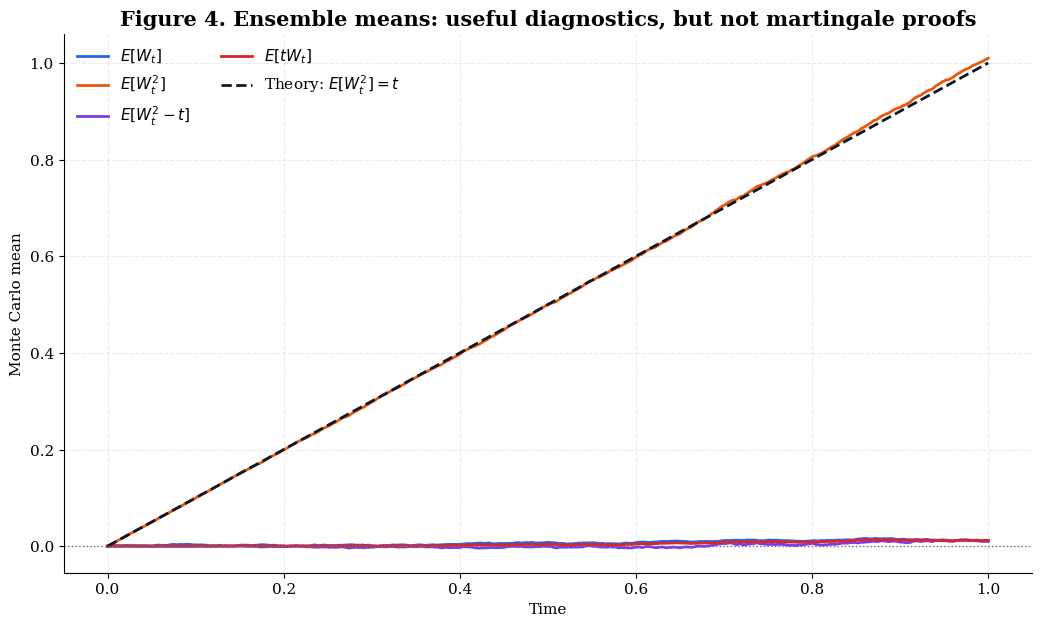

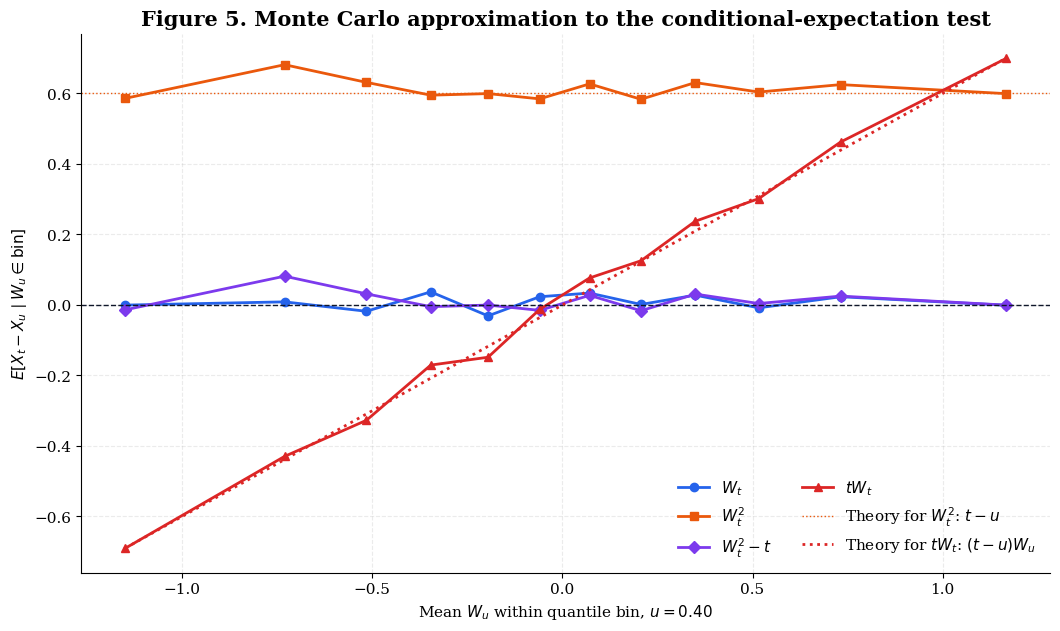

In [7]:

# Figure 4: ensemble means
fig, ax = plt.subplots(figsize=(12.5, 7))
mean_series = {
    "$E[W_t]$": (W.mean(axis=0), COLORS["blue"]),
    "$E[W_t^2]$": (W2.mean(axis=0), COLORS["orange"]),
    "$E[W_t^2-t]$": (W2_minus_t.mean(axis=0), COLORS["purple"]),
    "$E[tW_t]$": (tW.mean(axis=0), COLORS["red"])
}
for label, (values, color) in mean_series.items():
    ax.plot(time, values, label=label, color=color)

ax.plot(time, time, color=COLORS["dark"], linestyle="--",
        label="Theory: $E[W_t^2]=t$")
ax.axhline(0, color=COLORS["gray"], linewidth=1, linestyle=":")
ax.set_xlabel("Time")
ax.set_ylabel("Monte Carlo mean")
ax.set_title("Figure 4. Ensemble means: useful diagnostics, but not martingale proofs")
ax.grid(True)
ax.legend(ncol=2, loc="upper left")
save_show(fig, "Figure_4_Ensemble_Means.png")

# Conditional bins
u_index = int(round(U_TIME / dt))
terminal_index = N_STEPS
Wu = W[:, u_index]

edges = np.quantile(Wu, np.linspace(0, 1, N_BINS + 1))
edges[0] -= 1e-10
edges[-1] += 1e-10
bin_id = np.digitize(Wu, edges[1:-1])

process_map = {
    "$W_t$": W,
    "$W_t^2$": W2,
    "$W_t^2-t$": W2_minus_t,
    "$tW_t$": tW
}

rows = []
for b in range(N_BINS):
    mask = bin_id == b
    mean_wu = Wu[mask].mean()
    for name, values in process_map.items():
        gap = (values[mask, terminal_index] - values[mask, u_index]).mean()
        rows.append([b, mean_wu, name, gap, int(mask.sum())])

conditional_bins = pd.DataFrame(
    rows, columns=["bin", "mean_W_u", "process", "conditional_gap", "n"]
)

fig, ax = plt.subplots(figsize=(12.5, 7))
palette = {
    "$W_t$": COLORS["blue"],
    "$W_t^2$": COLORS["orange"],
    "$W_t^2-t$": COLORS["purple"],
    "$tW_t$": COLORS["red"]
}
markers = {"$W_t$": "o", "$W_t^2$": "s", "$W_t^2-t$": "D", "$tW_t$": "^"}

for name in process_map:
    subset = conditional_bins[conditional_bins["process"] == name]
    ax.plot(subset["mean_W_u"], subset["conditional_gap"],
            marker=markers[name], label=name, color=palette[name])

ax.axhline(0, color=COLORS["dark"], linewidth=1, linestyle="--")
ax.axhline(T - U_TIME, color=COLORS["orange"], linewidth=1,
           linestyle=":", label="Theory for $W_t^2$: $t-u$")

x_grid = np.linspace(conditional_bins["mean_W_u"].min(),
                     conditional_bins["mean_W_u"].max(), 100)
ax.plot(x_grid, (T - U_TIME) * x_grid,
        color=COLORS["red"], linestyle=":",
        label="Theory for $tW_t$: $(t-u)W_u$")

ax.set_xlabel(f"Mean $W_u$ within quantile bin, $u={U_TIME:.2f}$")
ax.set_ylabel("$E[X_t-X_u\\mid W_u\\in\\mathrm{bin}]$")
ax.set_title("Figure 5. Monte Carlo approximation to the conditional-expectation test")
ax.grid(True)
ax.legend(ncol=2, loc="best")
save_show(fig, "Figure_5_Conditional_Gaps.png")



## 6. Exponential compensation and variance identities

The raw exponential process satisfies

\[
E[e^{\theta W_t}]=e^{\theta^2t/2},
\]

whereas the compensated process

\[
M_t=\exp\left(\theta W_t-\frac12\theta^2t\right)
\]

has expectation one and zero Itô drift.

The final figure verifies two variance identities:

\[
\operatorname{Var}\left(\int_0^t s\,dW_s\right)
=\int_0^t s^2\,ds
=\frac{t^3}{3},
\]

and, after stochastic Fubini,

\[
\int_0^t W_s\,ds
=\int_0^t(t-u)\,dW_u,
\qquad
\operatorname{Var}\left(\int_0^t W_s\,ds\right)
=\frac{t^3}{3}.
\]


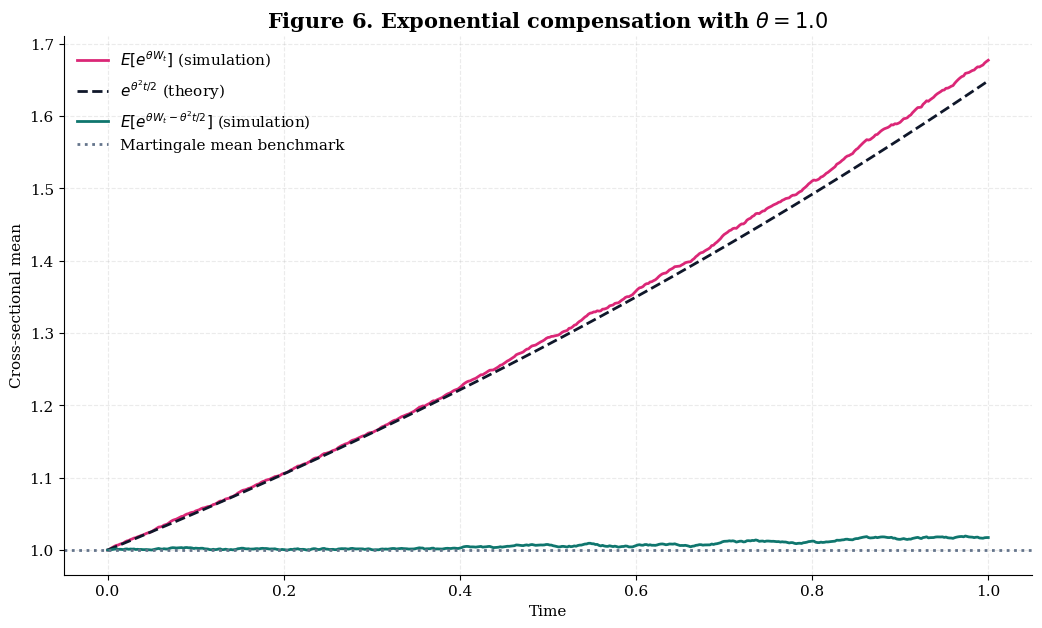

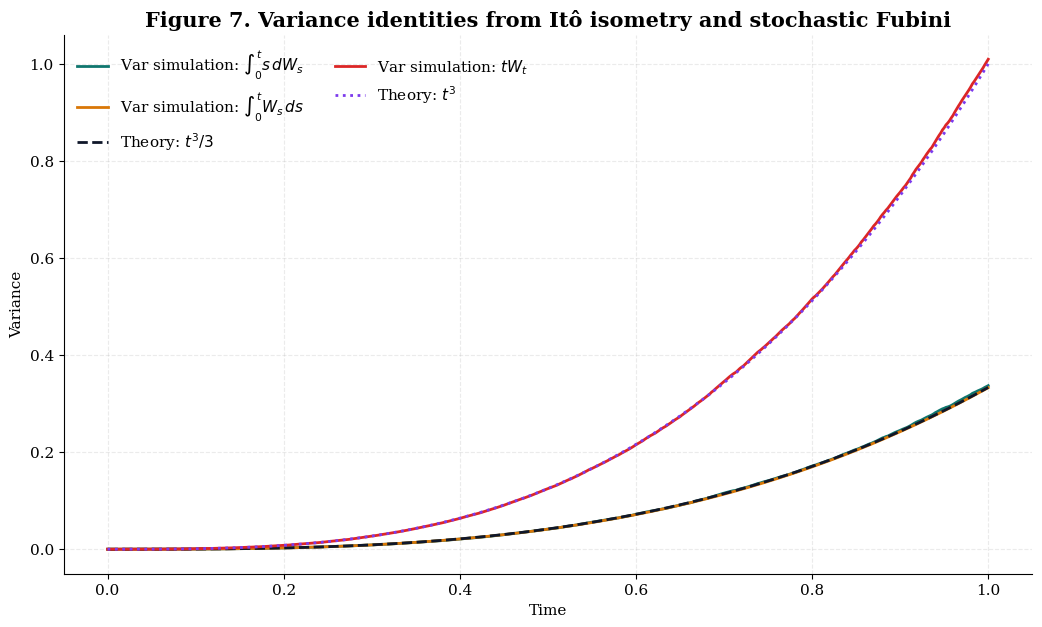

In [8]:

# Figure 6: exponential processes
fig, ax = plt.subplots(figsize=(12.5, 7))
ax.plot(time, Exp_raw.mean(axis=0),
        label="$E[e^{\\theta W_t}]$ (simulation)", color=COLORS["pink"])
ax.plot(time, np.exp(0.5 * THETA**2 * time),
        label="$e^{\\theta^2t/2}$ (theory)", color=COLORS["dark"], linestyle="--")
ax.plot(time, Exp_mart.mean(axis=0),
        label="$E[e^{\\theta W_t-\\theta^2t/2}]$ (simulation)", color=COLORS["teal"])
ax.axhline(1, color=COLORS["gray"], linestyle=":",
           label="Martingale mean benchmark")
ax.set_xlabel("Time")
ax.set_ylabel("Cross-sectional mean")
ax.set_title(f"Figure 6. Exponential compensation with $\\theta={THETA:.1f}$")
ax.grid(True)
ax.legend(loc="upper left")
save_show(fig, "Figure_6_Exponential_Martingale.png")

# Figure 7: variance identities
emp_var_s_dW = np.var(Ito_s_dW, axis=0, ddof=1)
emp_var_W_ds = np.var(Time_W_ds, axis=0, ddof=1)
emp_var_tW = np.var(tW, axis=0, ddof=1)

fig, ax = plt.subplots(figsize=(12.5, 7))
ax.plot(time, emp_var_s_dW,
        label="Var simulation: $\\int_0^t s\\,dW_s$", color=COLORS["teal"])
ax.plot(time, emp_var_W_ds,
        label="Var simulation: $\\int_0^t W_s\\,ds$", color=COLORS["gold"])
ax.plot(time, time**3 / 3,
        label="Theory: $t^3/3$", color=COLORS["dark"], linestyle="--")
ax.plot(time, emp_var_tW,
        label="Var simulation: $tW_t$", color=COLORS["red"])
ax.plot(time, time**3,
        label="Theory: $t^3$", color=COLORS["purple"], linestyle=":")
ax.set_xlabel("Time")
ax.set_ylabel("Variance")
ax.set_title("Figure 7. Variance identities from Itô isometry and stochastic Fubini")
ax.grid(True)
ax.legend(ncol=2, loc="upper left")
save_show(fig, "Figure_7_Variance_Identities.png")



## 7. Numerical result tables

Table 4 compares simulated terminal moments with their exact values. Table 5 evaluates the binned conditional-gap experiment against the theoretical gap function. These diagnostics should be read together with the analytical proofs in the paper.


In [9]:

terminal_processes = [
    ("$W_T$", W[:, -1], 0.0, T),
    ("$W_T^2$", W2[:, -1], T, 2*T**2),
    ("$W_T^2-T$", W2_minus_t[:, -1], 0.0, 2*T**2),
    (r"$\int_0^T W_s\,dW_s$", Ito_W_dW[:, -1], 0.0, 0.5*T**2),
    (r"$\int_0^T W_s\,ds$", Time_W_ds[:, -1], 0.0, T**3/3),
    ("$TW_T$", tW[:, -1], 0.0, T**3),
    (r"$\int_0^T s\,dW_s$", Ito_s_dW[:, -1], 0.0, T**3/3),
    (r"$e^{\theta W_T}$", Exp_raw[:, -1],
     np.exp(0.5*THETA**2*T),
     np.exp(2*THETA**2*T) - np.exp(THETA**2*T)),
    (r"$e^{\theta W_T-\theta^2T/2}$", Exp_mart[:, -1],
     1.0, np.exp(THETA**2*T) - 1.0)
]

table4_rows = []
for name, values, theoretical_mean, theoretical_var in terminal_processes:
    mc_mean = values.mean()
    mc_var = values.var(ddof=1)
    table4_rows.append([
        name, mc_mean, theoretical_mean, mc_mean-theoretical_mean,
        mc_var, theoretical_var, mc_var-theoretical_var
    ])

table4 = pd.DataFrame(table4_rows, columns=[
    "Process", "MC mean", "Theory mean", "Mean error",
    "MC variance", "Theory variance", "Variance error"
])

theory_functions = {
    "$W_t$": lambda x: np.zeros_like(x),
    "$W_t^2$": lambda x: np.full_like(x, T-U_TIME),
    "$W_t^2-t$": lambda x: np.zeros_like(x),
    "$tW_t$": lambda x: (T-U_TIME)*x
}

table5_rows = []
for name in process_map:
    subset = conditional_bins[conditional_bins["process"] == name].copy()
    theory_gap = theory_functions[name](subset["mean_W_u"].to_numpy())
    error = subset["conditional_gap"].to_numpy() - theory_gap
    table5_rows.append([
        name,
        float(np.sqrt(np.mean(error**2))),
        float(np.mean(np.abs(error))),
        float(np.max(np.abs(error))),
        "Near zero" if name in ["$W_t$", "$W_t^2-t$"] else "Systematically nonzero"
    ])

table5 = pd.DataFrame(table5_rows, columns=[
    "Process", "RMSE versus theoretical gap", "Mean absolute error",
    "Maximum absolute error", "Theoretical martingale-gap pattern"
])

table4.to_csv(OUTPUT_DIR / "Table_4.csv", index=False)
table5.to_csv(OUTPUT_DIR / "Table_5.csv", index=False)
conditional_bins.to_csv(OUTPUT_DIR / "Conditional_Bin_Details.csv", index=False)

display(
    table4.style
    .format({
        "MC mean": "{:.5f}", "Theory mean": "{:.5f}", "Mean error": "{:.5f}",
        "MC variance": "{:.5f}", "Theory variance": "{:.5f}", "Variance error": "{:.5f}"
    })
    .set_caption("Table 4. Monte Carlo terminal-moment diagnostics")
    .hide(axis="index")
)

display(
    table5.style
    .format({
        "RMSE versus theoretical gap": "{:.5f}",
        "Mean absolute error": "{:.5f}",
        "Maximum absolute error": "{:.5f}"
    })
    .set_caption("Table 5. Accuracy of the conditional-gap experiment")
    .hide(axis="index")
)


Process,MC mean,Theory mean,Mean error,MC variance,Theory variance,Variance error
$W_T$,0.01187,0.00000,0.01187,1.00964,1.00000,0.00964
$W_T^2$,1.00970,1.00000,0.00970,2.03104,2.00000,0.03104
$W_T^2-T$,0.00970,0.00000,0.00970,2.03104,2.00000,0.03104
"$\int_0^T W_s\,dW_s$",0.00491,0.00000,0.00491,0.50689,0.50000,0.00689
"$\int_0^T W_s\,ds$",0.00663,0.00000,0.00663,0.33288,0.33333,-0.00045
$TW_T$,0.01187,0.00000,0.01187,1.00964,1.00000,0.00964
"$\int_0^T s\,dW_s$",0.00522,0.00000,0.00522,0.33708,0.33333,0.00374
$e^{\theta W_T}$,1.67724,1.64872,0.02851,4.77049,4.67077,0.09971
$e^{\theta W_T-\theta^2T/2}$,1.01729,1.00000,0.01729,1.75496,1.71828,0.03668


Process,RMSE versus theoretical gap,Mean absolute error,Maximum absolute error,Theoretical martingale-gap pattern
$W_t$,0.02201,0.01781,0.03718,Near zero
$W_t^2$,0.02990,0.02097,0.08166,Systematically nonzero
$W_t^2-t$,0.02990,0.02097,0.08166,Near zero
$tW_t$,0.02201,0.01781,0.03718,Systematically nonzero



## 8. Reproducibility summary

The output folder should contain:

- `Figure_1_Recognition_Workflow.png`
- `Figure_2_Brownian_Transformations.png`
- `Figure_3_tW_Decomposition.png`
- `Figure_4_Ensemble_Means.png`
- `Figure_5_Conditional_Gaps.png`
- `Figure_6_Exponential_Martingale.png`
- `Figure_7_Variance_Identities.png`
- `Table_1.csv` through `Table_5.csv`
- `Conditional_Bin_Details.csv`

For a lighter run, reduce `N_PATHS` to 5,000. For smoother Monte Carlo curves on a machine with sufficient memory, increase it to 25,000 or more. The analytical conclusions do not depend on the simulation.


In [10]:

files_created = sorted(p.name for p in OUTPUT_DIR.iterdir() if p.is_file())
print("Files created:")
for name in files_created:
    print(" -", name)

expected = {
    *(f"Figure_{i}_" for i in range(1, 8)),
}
assert len([f for f in files_created if f.endswith(".png")]) == 7
assert len([f for f in files_created if f.startswith("Table_") and f.endswith(".csv")]) == 5
print("\nAll seven figures and five main tables were generated successfully.")


Files created:
 - Conditional_Bin_Details.csv
 - Figure_1_Recognition_Workflow.png
 - Figure_2_Brownian_Transformations.png
 - Figure_3_tW_Decomposition.png
 - Figure_4_Ensemble_Means.png
 - Figure_5_Conditional_Gaps.png
 - Figure_6_Exponential_Martingale.png
 - Figure_7_Variance_Identities.png
 - Table_1.csv
 - Table_2.csv
 - Table_3.csv
 - Table_4.csv
 - Table_5.csv

All seven figures and five main tables were generated successfully.
